In [2]:
import sys
!{sys.executable} -m pip install osmnx mapclassify
import osmnx as ox
import mapclassify


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
G = ox.graph_from_address("Toulouse, France", dist=50000, network_type="drive")
# {"all", "all_public", "bike", "drive", "drive_service", "walk"}

print("Graph loaded with {num_nodes} nodes and {num_edges} edges.".format(num_nodes=len(G.nodes), num_edges=len(G.edges)))
start_lon, start_lat = 1.072540,43.306193
end_lon, end_lat = 1.799011,43.852355

start_node = ox.distance.nearest_nodes(G, start_lon, start_lat)
end_node = ox.distance.nearest_nodes(G, end_lon, end_lat)


print("Start Node: {start_node},End Node: {end_node}".format(start_node=start_node, end_node=end_node))


Graph loaded with 95101 nodes and 219282 edges.
Start Node: 1613039070,End Node: 9314473359


In [4]:
route_nodes = ox.routing.shortest_path(G, start_node, end_node, weight="length")



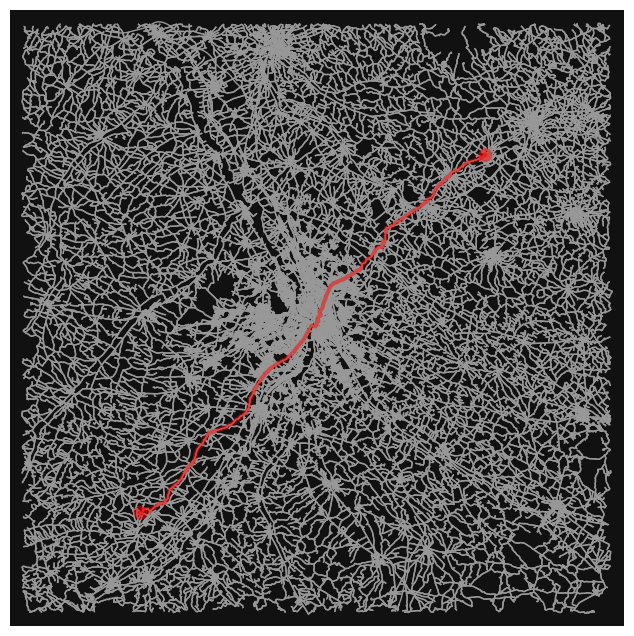

In [5]:
# plot the shortes path
fig, ax = ox.plot_graph_route(G, route_nodes, route_color="r", route_linewidth=3, node_size=0)
                              

In [6]:
print(route_nodes)

[1613039070, 1613039059, 1613039071, 1613039221, 1613039117, 1251694914, 1251694429, 1251687365, 1422477074, 7462274848, 11411599575, 1251698757, 380350496, 380349005, 380349029, 380350462, 380350368, 380350526, 380350361, 370109617, 574701143, 370109587, 380350530, 380350406, 6860114549, 1422470230, 1614189596, 380350610, 1614189931, 3951422944, 1422451856, 380349937, 1422452040, 1422452050, 1422452061, 380363849, 1422452096, 1422452122, 574701150, 1422452185, 1614190480, 1422452201, 1601237516, 6844650162, 2861912287, 380363735, 380363744, 1614191213, 3951434573, 1614191426, 380364037, 1594968156, 1594968295, 3212789945, 1594968374, 1594968421, 255870960, 380363495, 380364088, 387227034, 1594968960, 255870668, 1594968935, 7391906699, 387227047, 246627729, 246627721, 8828926984, 247471414, 560826409, 247471416, 247471417, 247471217, 560826431, 4437764785, 4437764768, 4437764771, 4437764787, 1571169987, 247790074, 1569996819, 1569831947, 1569247099, 1377437116, 1377437129, 1377436811, 

In [7]:
route_gdf = ox.routing.route_to_gdf(G, route_nodes)
route_gdf.explore(color="red", style_kwds={"weight": 1})


In [9]:
# 1. Calcul des vitesses et temps de trajet sur le graphe
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# 2. Conversion de la route en GeoDataFrame
route_gdf = ox.routing.route_to_gdf(G, route_nodes)

# 3. Agrégation des données
total_distance_km = route_gdf['length'].sum() / 1000
total_time_min = route_gdf['travel_time'].sum() / 60

print(f"Distance : {total_distance_km:.2f} km")
print(f"Temps estimé : {total_time_min:.1f} min")

Distance : 93.68 km
Temps estimé : 107.6 min


In [12]:
# Calcul du chemin le plus rapide
route_nodes_travel_time = ox.routing.shortest_path(G, start_node, end_node, weight="travel_time")

route_gdf_travel_time = ox.routing.route_to_gdf(G, route_nodes_travel_time)
route_gdf_travel_time.explore(color="blue", style_kwds={"weight": 1})

In [ ]:

import pandas as pd
modes = ["walk", "bike", "drive"]

# Vitesses effectives en km/h (déjà un peu dégradées vs maxspeed)
speeds = {
    "walk": {"residential": 5, "tertiary": 5, "footway": 4.5, "pedestrian": 4.5,
             "path": 4.5, "steps": 2, "living_street": 5, "service": 5,
             "unclassified": 5, "secondary": 5, "primary": 5},
    "bike": {"residential": 15, "tertiary": 18, "cycleway": 20, "living_street": 10,
             "secondary": 16, "primary": 16, "unclassified": 14, "path": 10},
    "drive": {"motorway": 100, "trunk": 80, "primary": 50, "secondary": 45,
              "tertiary": 40, "residential": 25, "unclassified": 30, "service": 15},
}
fallbacks = {"walk": 5, "bike": 14, "drive": 30}

# Pénalités en secondes par occurrence sur le trajet
# (moyennes : moitié du cycle pour un feu, etc.)
penalties = {
    "drive": {"traffic_signals": 20, "stop": 5, "give_way": 2, "crossing": 0,
              "mini_roundabout": 3, "parking": 120},
    "bike":  {"traffic_signals": 15, "stop": 2, "give_way": 1, "crossing": 0,
              "mini_roundabout": 2, "parking": 60},
    "walk":  {"traffic_signals": 12, "stop": 0, "give_way": 0, "crossing": 8,
              "mini_roundabout": 0, "parking": 0},
}


all_routes = []

all_graphs = {}

for mode in modes:
    G = ox.graph_from_address("Toulouse, France", dist=10000, network_type=mode)

    # Mise à jour des vitesses et temps de trajet
    for u, v, k, data in G.edges(keys=True, data=True):
        hwy = data.get("highway")
        if isinstance(hwy, list):
            hwy = hwy[0]
        data["speed_kph"] = speeds[mode].get(hwy, fallbacks[mode])
    G = ox.add_edge_travel_times(G)
    all_graphs[mode] = G



In [45]:
start = (1.479092839650062, 43.60289964770299)
end = (1.431665487237536, 43.605701457103905)
summary = []

for mode in modes:
    G = all_graphs[mode]

    orig = ox.distance.nearest_nodes(G, start[0], start[1])
    dest = ox.distance.nearest_nodes(G, end[0], end[1])
    route_nodes = ox.routing.shortest_path(G, orig, dest, weight="travel_time")
    if not route_nodes:
        print(f"{mode}: pas de route")
        continue

    gdf = ox.routing.route_to_gdf(G, route_nodes)

    # Comptage des éléments d'infrastructure traversés
    counts = {"traffic_signals": 0, "stop": 0, "give_way": 0,
              "crossing": 0, "mini_roundabout": 0}
    # On exclut origine et destination (on ne s'arrête pas "chez soi")
    for n in route_nodes[1:-1]:
        tag = G.nodes[n].get("highway")
        if tag in counts:
            counts[tag] += 1

    free_flow_s = gdf["travel_time"].sum()
    penalty_s = sum(counts[k] * penalties[mode][k] for k in counts)
    park_time = penalties[mode].get("parking", 0)*2 
    realistic_s = free_flow_s + penalty_s+park_time

    distance_km = gdf["length"].sum() / 1000
    summary.append({
        "mode": mode,
        "distance_km": round(distance_km, 2),
        "free_flow_min": round(free_flow_s / 60, 1),
        "penalty_min": round(penalty_s / 60, 1),
        "parking_min": round(park_time / 60, 1),
        "realistic_min": round(realistic_s / 60, 0),
        "n_signals": counts["traffic_signals"],
        "n_stops": counts["stop"],
        "n_crossings": counts["crossing"],
    })

    gdf["mode"] = mode
    all_routes.append(gdf)

print(pd.DataFrame(summary).to_string(index=False))
pd.concat(all_routes).explore(column="mode", cmap="Set1")

 mode  distance_km  free_flow_min  penalty_min  parking_min  realistic_min  n_signals  n_stops  n_crossings
 walk         4.47           55.2          1.9          0.0           57.0          0        0           14
 bike         5.20           18.9          1.0          2.0           22.0          4        0            0
drive         5.35            7.4          1.1          4.0           12.0          3        0            0


In [48]:
import pandas as pd
import re

# Source https://www.tomtom.com/traffic-index/city/toulouse

drive_city_speeds = """
Mon Tue Wed Thu Fri Sat Sun
12:00am45 km/h 45 km/h 44 km/h 44 km/h 43 km/h 43 km/h 44 km/h 44 km/h 43 km/h 42 km/h 42 km/h 42 km/h 43 km/h 44 km/h
02:00am45 km/h 44 km/h 43 km/h 42 km/h 42 km/h 42 km/h 43 km/h 48 km/h 48 km/h 47 km/h 46 km/h 43 km/h 43 km/h 42 km/h
04:00am54 km/h 53 km/h 52 km/h 51 km/h 48 km/h 46 km/h 44 km/h 57 km/h 56 km/h 55 km/h 54 km/h 52 km/h 48 km/h 45 km/h
06:00am57 km/h 57 km/h 57 km/h 57 km/h 57 km/h 52 km/h 49 km/h 37 km/h 37 km/h 39 km/h 38 km/h 44 km/h 54 km/h 52 km/h
08:00am28 km/h 28 km/h 32 km/h 29 km/h 38 km/h 55 km/h 54 km/h 37 km/h 37 km/h 40 km/h 38 km/h 44 km/h 51 km/h 52 km/h
10:00am45 km/h 44 km/h 44 km/h 44 km/h 44 km/h 48 km/h 50 km/h 45 km/h 43 km/h 43 km/h 43 km/h 43 km/h 45 km/h 48 km/h
12:00pm44 km/h 42 km/h 41 km/h 42 km/h 41 km/h 44 km/h 47 km/h 44 km/h 43 km/h 42 km/h 43 km/h 44 km/h 45 km/h 48 km/h
02:00pm44 km/h 43 km/h 42 km/h 43 km/h 43 km/h 45 km/h 48 km/h 44 km/h 43 km/h 42 km/h 43 km/h 40 km/h 44 km/h 48 km/h
04:00pm38 km/h 36 km/h 37 km/h 36 km/h 32 km/h 44 km/h 48 km/h 31 km/h 28 km/h 32 km/h 29 km/h 28 km/h 43 km/h 47 km/h
06:00pm34 km/h 31 km/h 33 km/h 31 km/h 33 km/h 42 km/h 46 km/h 41 km/h 39 km/h 38 km/h 38 km/h 38 km/h 41 km/h 44 km/h
08:00pm42 km/h 42 km/h 41 km/h 41 km/h 41 km/h 41 km/h 44 km/h 42 km/h 42 km/h 41 km/h 41 km/h 42 km/h 41 km/h 44 km/h
10:00pm42 km/h 42 km/h 42 km/h 42 km/h 42 km/h 42 km/h 44 km/h 44 km/h 43 km/h 43 km/h 42 km/h 43 km/h 43 km/h 45 km/h
"""

# Extraction de toutes les valeurs numériques (vitesse)
df_drive_city_speeds = [int(x) for x in re.findall(r'(\d+)\s*km/h', drive_city_speeds)]

# Reshape des données : 24 heures (lignes) x 7 jours (colonnes)
# Les données sont fournies par blocs de 14 (7 jours pour l'heure H, puis 7 jours pour l'heure H+1)
df = pd.DataFrame(
    data=[df_drive_city_speeds[i:i+7] for i in range(0, len(df_drive_city_speeds), 7)],
    columns=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    index=[f"{h:02d}:00" for h in range(24)]
)

print("Vitesse moyenne en km/h pour la conduite en ville à Toulouse :")
print(df)



# Données brutes extraites
drive_metro_speeds = [
    50, 49, 48, 48, 48, 48, 48, 49, 48, 47, 46, 46, 48, 48, # 00:00 - 01:00
    50, 49, 48, 47, 47, 47, 47, 53, 52, 51, 50, 48, 47, 47, # 02:00 - 03:00
    57, 56, 55, 54, 52, 50, 48, 59, 58, 58, 57, 56, 53, 49, # 04:00 - 05:00
    58, 57, 57, 57, 58, 56, 53, 39, 39, 42, 40, 46, 58, 56, # 06:00 - 07:00
    32, 32, 36, 33, 41, 57, 57, 41, 41, 44, 42, 47, 53, 55, # 08:00 - 09:00
    48, 46, 46, 47, 47, 49, 52, 47, 46, 45, 46, 46, 47, 51, # 10:00 - 11:00
    46, 45, 43, 45, 44, 47, 51, 47, 46, 45, 46, 46, 48, 52, # 12:00 - 13:00
    47, 46, 45, 46, 46, 48, 53, 46, 45, 45, 46, 44, 46, 53, # 14:00 - 15:00
    41, 39, 41, 40, 37, 46, 53, 35, 33, 36, 34, 34, 45, 52, # 16:00 - 17:00
    38, 35, 37, 36, 39, 45, 51, 45, 43, 43, 42, 43, 45, 50, # 18:00 - 19:00
    46, 46, 45, 45, 46, 45, 50, 46, 46, 46, 46, 47, 45, 49, # 20:00 - 21:00
    46, 46, 46, 46, 47, 46, 49, 48, 47, 47, 47, 47, 47, 50  # 22:00 - 23:00
]

# Reconstruction de la matrice (24 heures x 7 jours)
df_drive_metro_speeds = [drive_metro_speeds[i:i+7] for i in range(0, len(drive_metro_speeds), 7)]

# Création du DataFrame
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
hours = [f"{h:02d}:00" for h in range(24)]

df = pd.DataFrame(df_drive_metro_speeds, index=hours, columns=days)

print("Vitesse moyenne en km/h pour la conduite en métropole à Toulouse :")
print(df)

Vitesse moyenne en km/h pour la conduite en ville à Toulouse :
       Mon  Tue  Wed  Thu  Fri  Sat  Sun
00:00   45   45   44   44   43   43   44
01:00   44   43   42   42   42   43   44
02:00   45   44   43   42   42   42   43
03:00   48   48   47   46   43   43   42
04:00   54   53   52   51   48   46   44
05:00   57   56   55   54   52   48   45
06:00   57   57   57   57   57   52   49
07:00   37   37   39   38   44   54   52
08:00   28   28   32   29   38   55   54
09:00   37   37   40   38   44   51   52
10:00   45   44   44   44   44   48   50
11:00   45   43   43   43   43   45   48
12:00   44   42   41   42   41   44   47
13:00   44   43   42   43   44   45   48
14:00   44   43   42   43   43   45   48
15:00   44   43   42   43   40   44   48
16:00   38   36   37   36   32   44   48
17:00   31   28   32   29   28   43   47
18:00   34   31   33   31   33   42   46
19:00   41   39   38   38   38   41   44
20:00   42   42   41   41   41   41   44
21:00   42   42   41   41   42   41

In [39]:
import pandas as pd
import folium

# Fusion de tous les GeoDataFrames stockés dans la liste
routes_combinees = pd.concat(all_routes)

# Création de la carte avec une couleur distincte par mode de transport
m = routes_combinees.explore(
    column="mode", 
    cmap="Set1", 
    style_kwds={"weight": 5, "opacity": 0.8},
    legend=True
)

# 2. Ajout du point de départ (en vert)
folium.Marker(
    location=[start[0], start[1]],
    popup="Départ",
    icon=folium.Icon(color="green", icon="play")
).add_to(m)

# 3. Ajout du point d'arrivée (en rouge)
folium.Marker(
    location=[end[0], end[1]],
    popup="Arrivée",
    icon=folium.Icon(color="red", icon="stop")
).add_to(m)

# Affichage
display(m)

m
